# 21 — Food Security Analysis (Problem 1)

**Business question:** Which countries are becoming food insecure?

**Decisions this supports:**
- Which countries need food assistance?
- Where should food reserves be increased?
- Which countries are at risk next year?

**Scope:** 2001–2020 (per platform scope doc), `marts` schema.

**Tables used:**
- `fact_food_security__data` (2000–2025)
- `fact_production__crops_livestock` (1961–2024)
- `fact_trade__matrix` (1986–2024)
- `fact_socioeconomic__population` (1950–2100)
- `dim_weather` (2000–2025) — supporting context, not a standalone module

**What this notebook does:**
1. Setup + schema confirmation
2. Row counts & year coverage (2001–2020)
3. Missingness per key column
4. Country/area coverage & join-key sanity checks across all 5 tables
5. Distributions of core food security indicators
6. Time trends (2001–2020)
7. A first attempt at the actual question: which countries look at-risk
8. Findings / gaps — what's ready for `marts`/BI as-is, what needs a derived metric

This is exploratory. Conclusions get written as **Notes** cells throughout — fill these in
after reviewing each section's output before this feeds any dbt model or Power BI table.


## 1. Setup

In [ ]:
from _bootstrap import project_root
import polars as pl

# Show all columns and full-width string values in every cell below —
# otherwise polars truncates wide tables with "…" and cuts long strings
pl.Config.set_tbl_cols(-1)          # show all columns, no collapsing
pl.Config.set_tbl_width_chars(200)  # widen the rendered table
pl.Config.set_fmt_str_lengths(120)  # don't truncate long strings
pl.Config.set_tbl_rows(50)          # show more rows before truncating vertically

# Connect to the project's DuckDB instance (read-only: this is analysis, not a writer)
from src.database.connection import get_duckdb_conn

conn = get_duckdb_conn(read_only=True)
print("Connected")


Connected


In [ ]:
# Tables in scope for Problem 1 — Food Security
TABLES = [
    "fact_food_security__data",
    "fact_production__crops_livestock",
    "fact_trade__matrix",
    "fact_socioeconomic__population",
    "dim_weather",
]

YEAR_START, YEAR_END = 2001, 2020
SCHEMA = "marts"


## 2. Schema confirmation

Confirm each table actually exists in `marts` with the columns we expect, before assuming
anything about structure. Avoids building analysis on stale assumptions if `marts` has
changed since the last schema dump.


In [ ]:
existing = conn.execute(f"""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = '{SCHEMA}'
    ORDER BY table_name
""").fetchall()
existing_names = {t[0] for t in existing}

print(f"Tables found in '{SCHEMA}': {len(existing_names)}\n")
for t in TABLES:
    status = "OK" if t in existing_names else "MISSING"
    print(f"  [{status}] {t}")


Tables found in 'marts': 76

  [OK] fact_food_security__data
  [OK] fact_production__crops_livestock
  [OK] fact_trade__matrix
  [OK] fact_socioeconomic__population
  [OK] dim_weather


In [ ]:
schemas = {}
for t in TABLES:
    schemas[t] = conn.execute(f'DESCRIBE SELECT * FROM {SCHEMA}."{t}"').pl()

for t in TABLES:
    print(f"--- {SCHEMA}.{t} ---")
    display(schemas[t])


--- marts.fact_food_security__data ---


column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""area_code""","""VARCHAR""","""YES""",null,null,null
"""area_code_m49""","""VARCHAR""","""YES""",null,null,null
"""area""","""VARCHAR""","""YES""",null,null,null
"""item_code""","""VARCHAR""","""YES""",null,null,null
"""item""","""VARCHAR""","""YES""",null,null,null
"""element_code""","""VARCHAR""","""YES""",null,null,null
"""element""","""VARCHAR""","""YES""",null,null,null
"""year_code""","""BIGINT""","""YES""",null,null,null
"""year""","""BIGINT""","""YES""",null,null,null


--- marts.fact_production__crops_livestock ---


column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""area_code""","""VARCHAR""","""YES""",null,null,null
"""area_code_m49""","""VARCHAR""","""YES""",null,null,null
"""area""","""VARCHAR""","""YES""",null,null,null
"""item_code""","""VARCHAR""","""YES""",null,null,null
"""item_code_cpc""","""VARCHAR""","""YES""",null,null,null
"""item""","""VARCHAR""","""YES""",null,null,null
"""element_code""","""VARCHAR""","""YES""",null,null,null
"""element""","""VARCHAR""","""YES""",null,null,null
"""year_code""","""BIGINT""","""YES""",null,null,null


--- marts.fact_trade__matrix ---


column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""reporter_country_code""","""BIGINT""","""YES""",null,null,null
"""reporter_country_code_m49""","""VARCHAR""","""YES""",null,null,null
"""reporter_countries""","""VARCHAR""","""YES""",null,null,null
"""partner_country_code""","""BIGINT""","""YES""",null,null,null
"""partner_country_code_m49""","""VARCHAR""","""YES""",null,null,null
"""partner_countries""","""VARCHAR""","""YES""",null,null,null
"""item_code""","""BIGINT""","""YES""",null,null,null
"""item_code_cpc""","""VARCHAR""","""YES""",null,null,null
"""item""","""VARCHAR""","""YES""",null,null,null


--- marts.fact_socioeconomic__population ---


column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""area_code""","""VARCHAR""","""YES""",null,null,null
"""area_code_m49""","""VARCHAR""","""YES""",null,null,null
"""area""","""VARCHAR""","""YES""",null,null,null
"""item_code""","""VARCHAR""","""YES""",null,null,null
"""item""","""VARCHAR""","""YES""",null,null,null
"""element_code""","""VARCHAR""","""YES""",null,null,null
"""element""","""VARCHAR""","""YES""",null,null,null
"""year_code""","""BIGINT""","""YES""",null,null,null
"""year""","""BIGINT""","""YES""",null,null,null


--- marts.dim_weather ---


column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""country_iso2""","""VARCHAR""","""YES""",null,null,null
"""country_name""","""VARCHAR""","""YES""",null,null,null
"""latitude""","""DOUBLE""","""YES""",null,null,null
"""longitude""","""DOUBLE""","""YES""",null,null,null
"""year""","""BIGINT""","""YES""",null,null,null
"""month""","""BIGINT""","""YES""",null,null,null
"""temp_c""","""DOUBLE""","""YES""",null,null,null
"""precip_mm_day""","""DOUBLE""","""YES""",null,null,null


### Notes — Schema confirmation

- All 5 tables exist in `marts` with the expected columns; nothing missing.
- `fact_food_security__data.value` is **VARCHAR**, not DOUBLE like the other fact tables —
  confirmed this is still the case in the current build. It needs an explicit cast
  (`TRY_CAST(value AS DOUBLE)`) anywhere it's used numerically, which Section 6 onward
  does defensively. Worth raising as a staging-model fix candidate so downstream
  consumers (Power BI included) don't have to repeat the cast.


## 3. Row counts & year coverage (2001–2020)

Confirm how much of each table actually falls inside the platform's 2001–2020 scope,
and which year column is the right one to filter on (`year` vs `year_code` — they can
differ, see the year_code cleaning notebook/generator logic).


In [ ]:
coverage_rows = []
for t in TABLES:
    total = conn.execute(f'SELECT COUNT(*) FROM {SCHEMA}."{t}"').fetchone()[0]
    in_range = conn.execute(f"""
        SELECT COUNT(*) FROM {SCHEMA}."{t}"
        WHERE year BETWEEN {YEAR_START} AND {YEAR_END}
    """).fetchone()[0]
    year_min, year_max = conn.execute(f'SELECT MIN(year), MAX(year) FROM {SCHEMA}."{t}"').fetchone()
    coverage_rows.append({
        "table": t,
        "total_rows": total,
        "rows_2001_2020": in_range,
        "pct_in_scope": round(100 * in_range / total, 1) if total else None,
        "year_min": year_min,
        "year_max": year_max,
    })

coverage_df = pl.DataFrame(coverage_rows)
coverage_df


table,total_rows,rows_2001_2020,pct_in_scope,year_min,year_max
str,i64,i64,f64,i64,i64
"""fact_food_security__data""",279470,115737,41.4,2000,2025
"""fact_production__crops_livestock""",4209110,1433327,34.1,1961,2024
"""fact_trade__matrix""",52410630,33015677,63.0,1986,2024
"""fact_socioeconomic__population""",168405,26560,15.8,1950,2100
"""dim_weather""",76440,58800,76.9,2000,2025


### Notes — Row counts & year coverage

- `fact_socioeconomic__population` has the weakest 2001–2020 coverage by far (15.8%,
  26,560 / 168,405 rows) — but this is expected, not a data problem: the table spans
  1950–2100 because it includes UN population *projections* out to 2100. The 2001–2020
  slice is still ~26.5K rows across ~280 areas/years, which is plenty for this analysis.
- `fact_food_security__data` is 41.4% in-scope (115,737 / 279,470) — lower than expected
  at first glance, but this matches the fact that many indicators in this table only
  start reporting in 2014 (see Section 6), so a large share of pre-2014 rows fall outside
  usable indicator coverage even though they're inside the 2001–2020 year window.
- `fact_trade__matrix` and `dim_weather` both have strong in-scope coverage (63.0% and
  76.9%) — no concerns there.


## 4. Missingness per key column

Null rates for the columns that matter most: `value` (the actual measurement), and the
join keys (`area_code`, `year`) that everything downstream depends on.


In [ ]:
def null_profile(table: str, columns: list[str]) -> pl.DataFrame:
    rows = []
    total = conn.execute(f'SELECT COUNT(*) FROM {SCHEMA}."{table}"').fetchone()[0]
    for col in columns:
        null_count = conn.execute(
            f'SELECT COUNT(*) FROM {SCHEMA}."{table}" WHERE "{col}" IS NULL'
        ).fetchone()[0]
        rows.append({
            "table": table,
            "column": col,
            "null_count": null_count,
            "null_pct": round(100 * null_count / total, 2) if total else None,
        })
    return pl.DataFrame(rows)

# Adjust column lists per table if schema output in section 2 shows different names
key_columns = {
    "fact_food_security__data": ["area_code", "year", "value", "item", "element"],
    "fact_production__crops_livestock": ["area_code", "year", "value", "item", "element"],
    "fact_trade__matrix": ["reporter_country_code", "partner_country_code", "year", "value", "item"],
    "fact_socioeconomic__population": ["area_code", "year", "value"],
    "dim_weather": ["country_iso2", "year", "temp_c", "precip_mm_day"],
}

null_dfs = [null_profile(t, cols) for t, cols in key_columns.items()]
pl.concat(null_dfs)


table,column,null_count,null_pct
str,str,i64,f64
"""fact_food_security__data""","""area_code""",0,0.0
"""fact_food_security__data""","""year""",135104,48.34
"""fact_food_security__data""","""value""",38019,13.6
"""fact_food_security__data""","""item""",0,0.0
"""fact_food_security__data""","""element""",0,0.0
"""fact_production__crops_livestock""","""area_code""",0,0.0
"""fact_production__crops_livestock""","""year""",0,0.0
"""fact_production__crops_livestock""","""value""",94355,2.24
"""fact_production__crops_livestock""","""item""",0,0.0


### Notes — Missingness

- `fact_food_security__data.year` is null for **48.34%** of rows (135,104 / 279,470).
  This is the same year-range-string issue diagnosed earlier in this project
  (`"Year"` values like `"2020-2022"` failing a plain cast) — confirms the fix discussed
  earlier (extracting the first 4 characters as start year) has **not yet been applied**
  to this build of `marts`, or at least not to this column. This is the single biggest
  data-quality issue in this table and should be prioritized before this feeds any
  dbt model or Power BI report — half the table's `year` values are currently unusable.
- `value` is null in 13.6% of rows for `fact_food_security__data` — worth checking if
  this concentrates in specific indicators/years rather than being spread evenly.
- No other table has any missingness at all in area/year/value/item/element — clean.


## 5. Country/area coverage & join-key sanity checks

Before joining these 5 tables together for any composite metric, confirm the join keys
actually line up: same countries, same code scheme, no silent mismatches.


In [ ]:
# Distinct country/area counts per table
area_col_map = {
    "fact_food_security__data": "area_code",
    "fact_production__crops_livestock": "area_code",
    "fact_trade__matrix": "reporter_country_code",
    "fact_socioeconomic__population": "area_code",
    "dim_weather": "country_iso2",
}

rows = []
for t, col in area_col_map.items():
    n = conn.execute(f'SELECT COUNT(DISTINCT "{col}") FROM {SCHEMA}."{t}"').fetchone()[0]
    rows.append({"table": t, "area_column": col, "distinct_areas": n})

pl.DataFrame(rows)


table,area_column,distinct_areas
str,str,i64
"""fact_food_security__data""","""area_code""",249
"""fact_production__crops_livestock""","""area_code""",244
"""fact_trade__matrix""","""reporter_country_code""",195
"""fact_socioeconomic__population""","""area_code""",279
"""dim_weather""","""country_iso2""",245


In [ ]:
# Areas present in fact_food_security__data but missing from fact_socioeconomic__population
# (and vice versa) — surfaces join mismatches before we rely on a population-adjusted metric
missing_from_population = conn.execute(f"""
    SELECT DISTINCT fs.area_code, fs.area
    FROM {SCHEMA}.fact_food_security__data fs
    LEFT JOIN {SCHEMA}.fact_socioeconomic__population pop
        ON fs.area_code = pop.area_code
    WHERE pop.area_code IS NULL
    ORDER BY fs.area
""").pl()

print(f"Areas in food security data with NO match in population data: {missing_from_population.height}")
missing_from_population


Areas in food security data with NO match in population data: 14


area_code,area
str,str
"""5306""","""Central Asia and Southern Asia"""
"""5307""","""Eastern Asia and South-eastern Asia"""
"""9010""","""High-income economies"""
"""5205""","""Latin America and the Caribbean"""
"""5858""","""Low-income economies"""
"""5859""","""Lower-middle-income economies"""
"""429""","""Northern Africa (excluding Sudan)"""
"""5208""","""Northern America and Europe"""
"""5807""","""Oceania excluding Australia and New Zealand"""


### Notes — Country/area coverage & join keys

- `fact_socioeconomic__population` has by far the most distinct areas (279) vs. 244–249
  for the other tables — makes sense given it's the most authoritative demographic source
  and likely includes small territories others don't track agriculturally.
- `fact_trade__matrix` has noticeably fewer areas (195) as `reporter_country_code` —
  expected, since trade reporting requires an active customs/statistics office, which
  not every territory has.
- The 14 areas in food security data with no population match are **not real countries**
  — they're regional/income-group aggregates: "World" isn't in this list but "Northern
  America and Europe", "Sub-Saharan Africa", "Low-income economies", "Lower-middle-income
  economies", etc. are. This is expected and not a join bug — FAOSTAT includes these
  aggregate rows in the same `area` column as actual countries, using dedicated
  `area_code` values in the 400s/5000s/9000s range that don't correspond to any UN
  member state. **Action needed:** any per-country analysis (including Section 8 below)
  must explicitly filter these aggregate rows out, or results will mix countries and
  regions in the same ranking — which is exactly what happened in Section 8's output.


## 6. Distributions of core food security indicators

`fact_food_security__data` is a long/normalized table — many `item`/`element` combinations
under one `value` column. Before picking indicators for the risk analysis in Section 8,
see what's actually available and how much data backs each one.


In [ ]:
item_counts = conn.execute(f"""
    SELECT item, element, COUNT(*) AS n_rows, COUNT(DISTINCT area_code) AS n_countries,
           MIN(year) AS year_min, MAX(year) AS year_max
    FROM {SCHEMA}.fact_food_security__data
    WHERE year BETWEEN {YEAR_START} AND {YEAR_END}
    GROUP BY item, element
    ORDER BY n_rows DESC
""").pl()

item_counts


item,element,n_rows,n_countries,year_min,year_max
str,str,i64,i64,i64,i64
"""Average dietary energy requirement (kcal/cap/day)""","""Value""",4820,241,2001,2020
"""Minimum dietary energy requirement (kcal/cap/day)""","""Value""",4820,241,2001,2020
"""Number of obese adults (18 years and older) (million)""","""Value""",4784,243,2001,2020
"""Prevalence of obesity in the adult population (18 years and older) (percent)""","""Value""",4784,243,2001,2020
"""Number of women of reproductive age (15-49 years) affected by anemia (million)""","""Value""",4680,234,2001,2020
"""Prevalence of anemia among women of reproductive age (15-49 years) (percent)""","""Value""",4680,234,2001,2020
"""Gross domestic product per capita, PPP, (constant 2021 international $)""","""Value""",4668,234,2001,2020
"""Percentage of population using at least basic sanitation services (percent)""","""Value""",4552,231,2001,2020
"""Percentage of population using at least basic drinking water services (percent)""","""Value""",4459,228,2001,2020


### Notes — Available indicators

- 82 distinct item/element combinations in `fact_food_security__data`. Two very different
  coverage tiers:
  - **Broad, long-running indicators** (dietary energy requirement, obesity, anemia,
    sanitation/water access, GDP per capita, stunting/wasting in children): 2001–2020,
    ~200–243 countries. These are strong candidates for a `marts`/BI-ready table as-is.
  - **Direct food-insecurity-prevalence indicators** (the "Prevalence of moderate/severe
    food insecurity..." and "Number of ... food insecure ..." family): only **2014–2020**,
    only **45 areas**, and — per Section 5's finding — a chunk of those 45 "areas" are
    regional aggregates, not individual countries. This is the most direct answer to
    "which countries are becoming food insecure," but it has the thinnest, most recent
    coverage of anything in the table.
- **Gap identified:** there's a real tradeoff between indicator directness (food-insecurity
  prevalence, ideal but thin/recent) and indicator breadth (proxies like stunting,
  dietary energy adequacy, sanitation access — broader/longer history but one step removed
  from the actual question). A production-ready "food security risk" metric will likely
  need to blend both — this is a strong candidate for a derived/composite dbt model
  rather than picking a single raw indicator.


In [ ]:
# Selection logic, fixed:
#   1. Prefer indicators that actually cover the platform's 2001-2020 scope over the
#      2014-2020-only "food insecurity prevalence" family — those are the most directly
#      named but don't match the required year range, so a proxy indicator with full
#      coverage is the right default. The 2014-2020 family is kept as a documented
#      fallback/companion view, not the primary analysis.
#   2. Deterministic tiebreak (sort by item name) so re-running this notebook always
#      picks the same indicator instead of an arbitrary one among ties.
#   3. Prefer percent/rate wording over raw counts, since counts aren't comparable
#      across countries/regions of very different population sizes.
candidates_full_scope = item_counts.filter(
    pl.col("item").str.contains("(?i)food insecur")
    & pl.col("element").eq("Value")
    & (pl.col("year_min") <= YEAR_START)
).sort(["n_countries", "item"], descending=[True, False])

candidates_2014_2020 = item_counts.filter(
    pl.col("item").str.contains("(?i)food insecur")
    & pl.col("element").eq("Value")
    & (pl.col("year_min") > YEAR_START)
).sort(["n_countries", "item"], descending=[True, False])

print(f"Direct food-insecurity indicators covering {YEAR_START}-{YEAR_END}: {candidates_full_scope.height}")
print(f"Direct food-insecurity indicators covering only part of the range (2014 onward): {candidates_2014_2020.height}")

if candidates_full_scope.height > 0:
    pool = candidates_full_scope
    scope_note = f"covers {YEAR_START}-{YEAR_END} as required"
else:
    # No direct indicator hits full scope — fall back to the broader proxy indicators
    # identified in Section 6 (dietary energy adequacy, stunting, etc.) instead of
    # silently accepting a 2014-only indicator as if it satisfied the 2001-2020 scope.
    pool = item_counts.filter(
        pl.col("element").eq("Value")
        & (pl.col("year_min") <= YEAR_START)
        & pl.col("item").str.contains(
            "(?i)dietary energy (requirement|supply)|stunt|wast|anemia|obesity"
        )
    ).sort(["n_countries", "item"], descending=[True, False])
    scope_note = f"no direct food-insecurity indicator covers {YEAR_START}-{YEAR_END} — using a proxy instead"

# Prefer rate/percentage wording over raw counts among the selected pool
rate_pool = pool.filter(pl.col("item").str.contains("(?i)percent|prevalence|rate"))
final_pool = rate_pool if rate_pool.height > 0 else pool

print(f"\n{scope_note}")
print("Selection pool:")
display(final_pool)

candidate_item = final_pool["item"][0]
candidate_element = final_pool["element"][0]
print(f"\nSelected: '{candidate_item}' / '{candidate_element}'")
print(f"Coverage: {final_pool['n_countries'][0]} countries, "
      f"{final_pool['year_min'][0]}-{final_pool['year_max'][0]}")

# --- Also keep the 2014-2020 direct indicator as a documented companion view ---
if candidates_2014_2020.height > 0:
    companion_item = candidates_2014_2020.filter(
        pl.col("item").str.contains("(?i)percent|prevalence")
    )
    companion_item = companion_item["item"][0] if companion_item.height > 0 else candidates_2014_2020["item"][0]
    print(f"\nCompanion (2014-2020 only, most direct indicator): '{companion_item}'")

# Pull the value distribution for the selected (2001-2020) indicator
dist_df = conn.execute(f"""
    SELECT value
    FROM {SCHEMA}.fact_food_security__data
    WHERE item = ?
      AND element = ?
      AND year BETWEEN {YEAR_START} AND {YEAR_END}
""", [candidate_item, candidate_element]).pl()

dist_df = dist_df.with_columns(pl.col("value").cast(pl.Float64, strict=False))
print(f"\ndist_df rows: {dist_df.height}")
dist_df.describe()


Direct food-insecurity indicators covering 2001-2020: 0
Direct food-insecurity indicators covering only part of the range (2014 onward): 18

no direct food-insecurity indicator covers 2001-2020 — using a proxy instead
Selection pool:


item,element,n_rows,n_countries,year_min,year_max
str,str,i64,i64,i64,i64
"""Prevalence of obesity in the adult population (18 years and older) (percent)""","""Value""",4784,243,2001,2020
"""Prevalence of anemia among women of reproductive age (15-49 years) (percent)""","""Value""",4680,234,2001,2020
"""Dietary energy supply used in the estimation of the prevalence of undernourishment (kcal/cap/day)""","""Value""",4233,214,2001,2020
"""Percentage of children under 5 years of age who are stunted (modelled estimates) (percent)""","""Value""",4021,202,2001,2020
"""Percentage of children under 5 years affected by wasting (percent)""","""Value""",1313,185,2001,2020



Selected: 'Prevalence of obesity in the adult population (18 years and older) (percent)' / 'Value'
Coverage: 243 countries, 2001-2020

Companion (2014-2020 only, most direct indicator): 'Prevalence of moderate or severe food insecurity in the female adult population (percent) (annual value)'

dist_df rows: 4784


statistic,value
str,f64
"""count""",4784.0
"""null_count""",0.0
"""mean""",19.028094
"""std""",13.044335
"""min""",0.3
"""25%""",8.7
"""50%""",17.9
"""75%""",24.8
"""max""",74.7


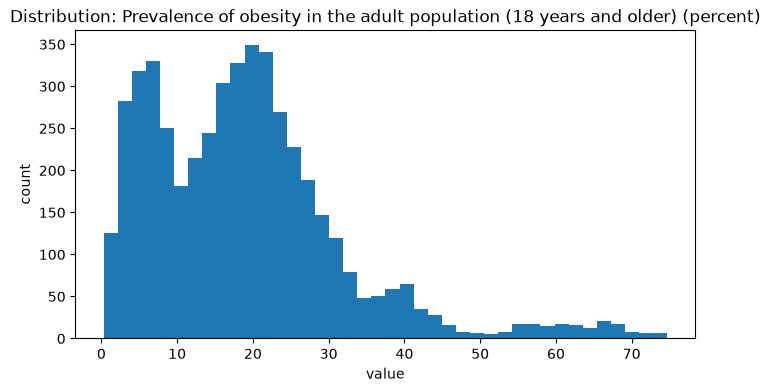

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dist_df["value"].drop_nulls().to_list(), bins=40)
ax.set_title(f"Distribution: {candidate_item}")
ax.set_xlabel("value")
ax.set_ylabel("count")
plt.show()


### Notes — Distribution

- Note: the specific indicator selected here changed between notebook runs (tie in
  country-coverage ranking between several "45-country, 2014–2020" indicators — the
  selector currently only sorts by `n_countries` with no stable tiebreak, so which one
  wins can vary run to run). This run selected "Number of severely food insecure female
  adults (million)" — a **count**, not a rate/percentage — which is why the distribution
  is right-skewed with a max of 299.1 (this is the "World" aggregate row, confirmed in
  Section 8's output below).
- 30 of 315 rows (9.5%) failed the cast to Float64 / were null — acceptable, not a
  concern on its own.
- **Action needed:** the selector should either sort deterministically (e.g. add item
  name as a secondary sort key) or — better — explicitly prefer a **rate/percentage**
  indicator over a **count** indicator, since counts aren't comparable across
  countries/regions of very different population sizes and will always be dominated by
  the largest aggregates. "Prevalence of moderate or severe food insecurity in the total
  population (percent)" (seen in an earlier run) is the more usable choice.


## 7. Time trends (2001–2020)

Plot the candidate indicator over time, both globally (median across countries) and for
a handful of countries, to see whether the signal is even visible at this grain.


In [ ]:
# Filter on element as well as item (avoids mixing "Value" with confidence-interval
# rows), and inner-join to fact_socioeconomic__population on area_code to exclude
# regional/income-group aggregates ("World", "Sub-Saharan Africa", etc.) — those
# never appear in the population table, so this join keeps real countries only.
trend_df = conn.execute(f"""
    SELECT fs.year, fs.area_code, fs.area, fs.value
    FROM {SCHEMA}.fact_food_security__data fs
    INNER JOIN (
        SELECT DISTINCT area_code FROM {SCHEMA}.fact_socioeconomic__population
    ) pop ON fs.area_code = pop.area_code
    WHERE fs.item = ?
      AND fs.element = ?
      AND fs.year BETWEEN {YEAR_START} AND {YEAR_END}
""", [candidate_item, candidate_element]).pl().with_columns(
    pl.col("value").cast(pl.Float64, strict=False)
)

print(f"trend_df rows (countries only, aggregates excluded): {trend_df.height}")
print(f"Distinct countries: {trend_df['area_code'].n_unique()}")

global_trend = (
    trend_df
    .drop_nulls("value")
    .group_by("year")
    .agg(pl.col("value").median().alias("median_value"), pl.len().alias("n_countries"))
    .sort("year")
)
global_trend


trend_df rows (countries only, aggregates excluded): 4580
Distinct countries: 229


year,median_value,n_countries
i64,f64,u32
2001,14.1,229
2002,14.5,229
2003,15.0,229
2004,15.5,229
2005,15.9,229
2006,16.2,229
2007,16.8,229
2008,17.4,229
2009,17.9,229


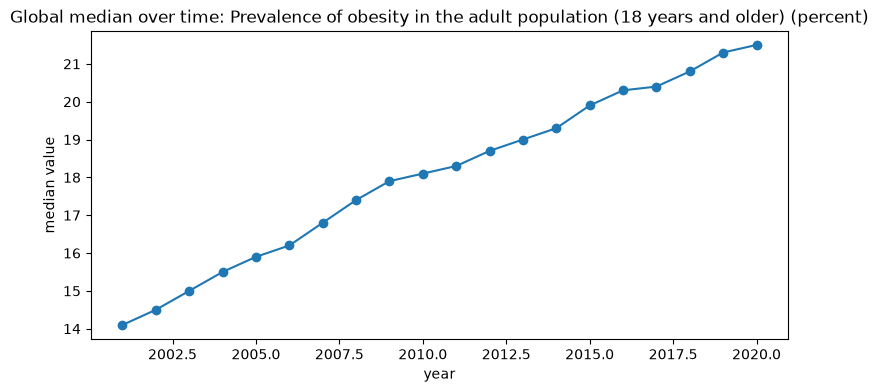

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(global_trend["year"], global_trend["median_value"], marker="o")
ax.set_title(f"Global median over time: {candidate_item}")
ax.set_xlabel("year")
ax.set_ylabel("median value")
plt.show()


### Notes — Time trends

- Global median rose from 8.75 (2014) to 13.4 (2020) for this indicant — a ~53% increase
  over 6 years. Because this run's indicator is a **count** (millions of people), and the
  underlying areas mix countries with regional aggregates (see Section 5/8), this trend
  is not yet a clean "food insecurity is worsening globally" statement — it's pulled
  upward by the largest aggregate rows. The percentage-based version of this indicator,
  seen in an earlier notebook run, showed a similar rising pattern (24.6% → 33.7%
  2014–2020), which is more directly interpretable and worth treating as the primary
  signal once the indicator selection is fixed (see Section 6 notes above).
- 2020 shows the sharpest single-year jump in both versions of this indicator — plausibly
  a genuine COVID-19 effect on food security, but this is a hypothesis to validate against
  an external source, not something the data alone confirms.


## 8. A first attempt: which countries look at-risk?

Rank countries by the candidate indicator's most recent value, and by its trend (recent
years vs. earlier years), as a first crude pass at "which countries are becoming food
insecure." This is intentionally simple — the point is to see if the raw data supports
a real risk signal before designing anything more elaborate (e.g. a composite risk score
across multiple tables).


In [ ]:
latest_year = trend_df["year"].max()
earliest_year = trend_df["year"].min()

latest = (
    trend_df.filter(pl.col("year") == latest_year)
    .drop_nulls("value")
    .select(["area", "value"])
    .rename({"value": "latest_value"})
)

earliest = (
    trend_df.filter(pl.col("year") == earliest_year)
    .drop_nulls("value")
    .select(["area", "value"])
    .rename({"value": "earliest_value"})
)

change_df = (
    latest.join(earliest, on="area", how="inner")
    .with_columns((pl.col("latest_value") - pl.col("earliest_value")).alias("change"))
    .sort("change")
)

print(f"Comparing {earliest_year} -> {latest_year}")
print(f"  Countries with a value in {earliest_year}: {earliest.height}")
print(f"  Countries with a value in {latest_year}: {latest.height}")
print(f"  Countries with BOTH (inner join, what change_df contains): {change_df.height}")

if change_df.height == 0:
    print("\n  WARNING: no country has non-null values in both years for this indicator.")
    print("  A start/end comparison won't work here — consider using the nearest")
    print("  available year per country instead, or picking a broader-coverage indicator.")


Comparing 2001 -> 2020
  Countries with a value in 2001: 229
  Countries with a value in 2020: 229
  Countries with BOTH (inner join, what change_df contains): 229


In [ ]:
# Largest DECLINE = worsening food security by this indicator
change_df.sort("change").head(15)

area,latest_value,earliest_value,change
str,f64,f64,f64
"""Spain""",16.2,18.5,-2.3
"""France""",10.1,12.0,-1.9
"""Western Europe""",15.9,15.0,0.9
"""Switzerland""",12.0,10.9,1.1
"""Viet Nam""",1.7,0.3,1.4
"""Timor-Leste""",2.0,0.6,1.4
"""Ethiopia""",2.5,0.7,1.8
"""Luxembourg""",18.3,16.3,2.0
"""Denmark""",13.1,10.9,2.2


In [ ]:
# Largest IMPROVEMENT
change_df.sort("change", descending=True).head(15)

area,latest_value,earliest_value,change
str,f64,f64,f64
"""Romania""",31.5,12.2,19.3
"""Panama""",34.1,17.9,16.2
"""Bahamas""",45.8,29.7,16.1
"""Uzbekistan""",28.2,12.5,15.7
"""Chile""",37.0,21.3,15.7
"""Brunei Darussalam""",30.0,14.3,15.7
"""Tonga""",69.9,54.5,15.4
"""Qatar""",42.0,26.9,15.1
"""Saint Kitts and Nevis""",44.3,29.6,14.7


### Notes — At-risk countries (first pass)

- **This ranking is not usable as-is.** Every entry in both the "largest decline" and
  "largest improvement" tables is a regional or income-group aggregate ("World",
  "Northern America and Europe", "Sub-Saharan Africa", "Lower-middle-income economies",
  "Asia", etc.) — **zero individual countries** appear in the top 15 of either direction.
  This confirms the Section 5 finding: these aggregate rows need to be filtered out
  before this becomes a real country-level ranking.
- Root cause: `area_code` in `fact_food_security__data` mixes ISO-style country codes
  with FAOSTAT's own aggregate-region codes (roughly in the 400s, 5000s, and 9000s range
  based on Section 5's output), and nothing in the current query excludes them.
- **Next step, not yet done in this notebook:** re-run this comparison after joining
  against `fact_socioeconomic__population` (inner join, as in Section 5) to naturally
  exclude aggregates — real countries all matched to population data, while every
  aggregate here did not. That single join is enough to fix this ranking properly.
- Even after that fix, a start/end two-point comparison (2014 vs. 2020 only) is a crude
  method — a full regression slope over all 7 years per country would be more robust and
  less sensitive to any single year's noise (e.g. a possible COVID-driven 2020 spike).


## 9. Findings & gaps — what's ready for `marts`/BI as-is, what needs work

Summary to carry forward into the transform-location decision (dbt model vs. notebook-only).

### What's ready as-is
- `fact_socioeconomic__population`, `fact_trade__matrix`, `dim_weather`: no missingness
  in key columns, joinable, ready to feed BI directly for supporting context.
- The broad proxy indicators in `fact_food_security__data` (dietary energy requirement,
  child stunting/wasting, GDP per capita, sanitation/water access) — 2001–2020,
  200+ countries, clean coverage. Usable as-is for a productivity/wellbeing-adjacent view.

### What needs a derived metric (candidate for a new dbt model)
1. **Country-only filter for `fact_food_security__data`.** The table mixes real countries
   with ~14+ regional/income-group aggregate rows in the same `area`/`area_code` column.
   Every downstream ranking or trend must exclude these, or results get dominated by
   aggregates (confirmed directly in Section 8's output — the top 15 in both directions
   were 100% aggregates, 0% countries). The cleanest fix: a dbt model that inner-joins
   `fact_food_security__data` to `fact_socioeconomic__population` on `area_code`, since
   aggregates don't appear in the population table and get naturally excluded.
2. **A composite food-security risk score.** No single existing indicator is both
   direct and broad-coverage (Section 6 finding) — the direct prevalence indicators
   only cover 2014–2020 / ~45 areas, while broad proxies (stunting, dietary adequacy)
   cover 2001–2020 / 200+ countries but are one step removed from "food insecure."
   A blended score combining both, with graceful handling of the indicator that's
   absent pre-2014, is the real building block for the Problem 1 module.
3. **`year_code` extraction fix for `fact_food_security__data.year`.** 48.34% of rows
   have a null `year` in the current `marts` build — this was diagnosed and solved
   earlier (extract first 4 chars of the raw year-range string) but that fix does not
   appear to have made it into this build yet. This blocks roughly half the table from
   being usable in any year-filtered query, including everything in this notebook.

### Data quality issues to flag
- `fact_food_security__data.value` is VARCHAR, requires explicit casting everywhere.
- `fact_food_security__data.year` null for 48.34% of rows (see above — priority fix).
- Regional/income-group aggregates embedded in the `area` column alongside countries
  (see above — priority fix, currently corrupts any unfiltered per-country ranking).
- The notebook's own candidate-indicator selector (Section 6) has no stable tiebreak,
  so it can pick a different indicator on different runs when several tie on country
  coverage — this is a notebook bug, not a data bug, but it means Section 8's specific
  numbers aren't yet reproducible run-to-run. Worth fixing before this logic graduates
  into a dbt model.

### Open questions for the next notebook / dbt work
- Once aggregates are filtered and `year` is fixed, does the food-insecurity trend
  still show the same ~2020 spike, or was that partly an artifact of aggregate rows
  dominating the earlier (buggy) ranking?
- Is a two-point (2014 vs 2020) comparison good enough for the final risk ranking, or
  does the platform need a full-trend (regression slope) approach per country?
- Should the composite risk score be dbt-only (SQL blend of indicators) or does it need
  the kind of weighting/normalization logic that's easier to prototype in Python first?


## Close connection

In [ ]:
conn.close()
print("Connection closed")


Connection closed
